# Media Representation Analysis — Week 7 Checkpoint
### Quantifying gender and ethnicity representation in US film and TV

This notebook analyzes cast data from 580 US productions (295 films, 285 TV shows) pulled from the TMDB API.
It examines who appears, what roles they get, and how prominent those roles are, broken down by gender, ethnicity, media type, genre, and decade.

**Key concepts used throughout:**
- **Prominence score**: Prominence score is a way of measuring how central an actor is to a production, based on their billing position.
The raw calculation is simply 1 / billing_order — so the actor billed first gets a score of 1.0, second gets 0.5, third gets 0.33, and so on. The key property is that it's nonlinear; the gap between position 1 and 2 is much larger than the gap between position 9 and 10, which reflects how cast hierarchies actually work. Being the lead of a film is qualitatively different from being second billed, in a way that a simple rank number doesn't capture.
Then those raw scores get normalized within each title, so all scores in a given film sum to 1.0. This means the score becomes a share and an actor with a prominence score of 0.38 accounts for 38% of the total prominence weight in that production. This makes scores comparable across titles with very different cast sizes, which matters when you're pooling movies and TV shows together.
A prominence score of 0.38 means top billing in a large cast. A score of 0.07 means somewhere in the middle of a large cast. A score of 0.02 means a minor role near the bottom of the billing. The percentage framing makes this intuitive: that actor "owns" that share of the production's starring weight.

- **Named characters only**: generic/uncredited roles (e.g. "Cop", "Pedestrian") are excluded from analysis.
- **Benjamini-Hochberg correction**: used for all statistical tests to control the false discovery rate across multiple comparisons, avoiding the inflated false positive risk of running many tests simultaneously.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, dtype=str)
df["billing_order"] = pd.to_numeric(df["billing_order"], errors="coerce")
df["prominence_score"] = pd.to_numeric(df["prominence_score"], errors="coerce")
df["start_year"] = pd.to_numeric(df["start_year"], errors="coerce")

named = df[df["is_named_character"] == "True"].copy()
named["decade"] = (named["start_year"] // 10 * 10).astype("Int64").astype(str) + "s"
named = named[named["decade"] != "<NA>s"].copy()
named["ethnicity_simple"] = named["actor_ethnicity"].apply(
    lambda x: "White" if x == "White" else ("Unknown" if x == "Unknown" else "Non-white")
)
named["genre_primary"] = named["genres"].str.split("|").str[0]
leads = named[named["role_type"] == "lead"]
ROLE_ORDER = ["lead", "supporting", "minor"]

GENDER_COLORS = {"female": "#E07B9A", "male": "#5B8DB8", "unspecified": "#B0B0B0"}
ETH_PALETTE = "Set2"

sns.set_theme(style="whitegrid", font_scale=1.1)
print(f"Loaded {len(named)} named characters across {named['title'].nunique()} titles")
print(f"Movies: {named[named['media_type']=='movie']['title'].nunique()} | TV: {named[named['media_type']=='tv']['title'].nunique()}")


Saving parsed_data_with_ethnicity_v2.csv to parsed_data_with_ethnicity_v2 (1).csv
Loaded 7491 named characters across 579 titles
Movies: 294 | TV: 286


## 1. Gender Trends Over Time

These charts track the percentage of female cast members and female leads across decades.
The prominence score line shows whether female actors' narrative centrality has changed over time,
independent of how many are cast.


/tmp/ipykernel_3707/760442545.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_decade = named.groupby("decade").apply(
/tmp/ipykernel_3707/760442545.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3707/760442545.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to s

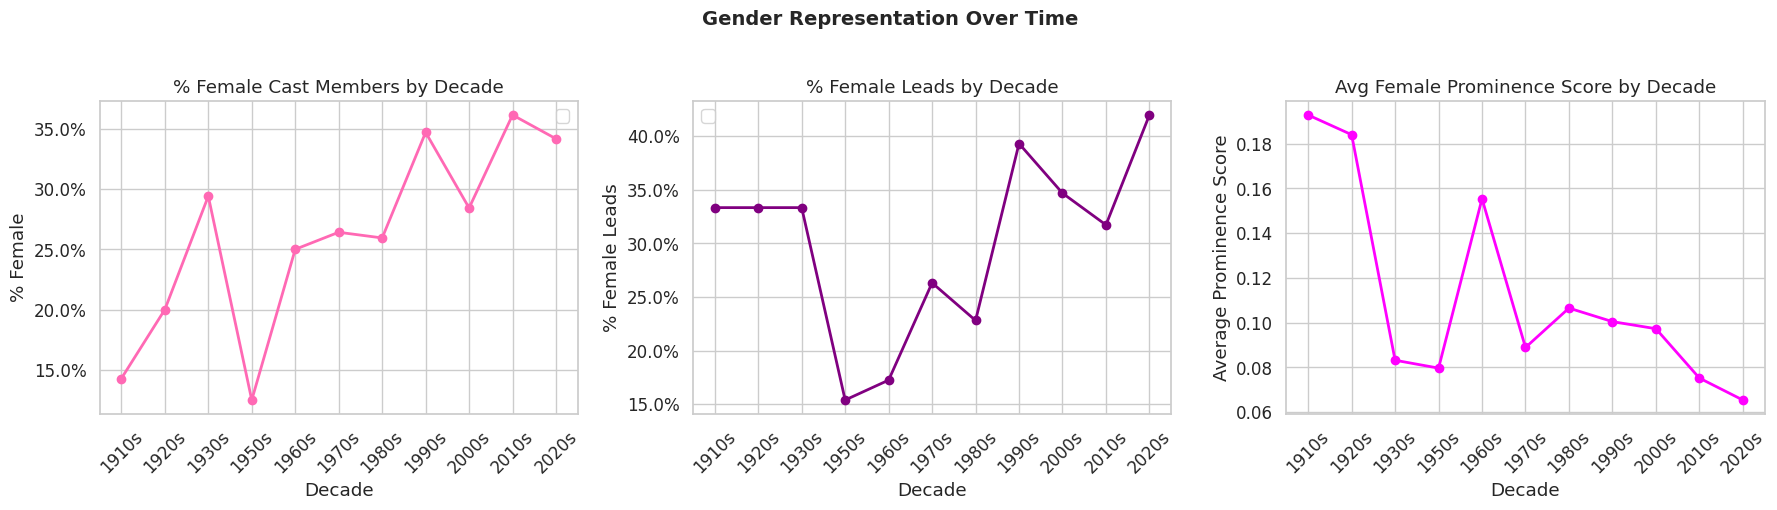

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# % female all roles by decade
gender_decade = named.groupby("decade").apply(
    lambda x: (x["actor_gender"] == "female").mean() * 100
).reset_index()
gender_decade.columns = ["decade", "pct_female"]
ax = axes[0]
ax.plot(gender_decade["decade"], gender_decade["pct_female"], marker="o", color="hotpink", linewidth=2)
ax.set_title("% Female Cast Members by Decade")
ax.set_ylabel("% Female")
ax.set_xlabel("Decade")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# % female leads by decade
gender_leads_decade = leads.groupby("decade").apply(
    lambda x: (x["actor_gender"] == "female").mean() * 100
).reset_index()
gender_leads_decade.columns = ["decade", "pct_female_lead"]
ax = axes[1]
ax.plot(gender_leads_decade["decade"], gender_leads_decade["pct_female_lead"], marker="o", color="purple", linewidth=2)
ax.set_title("% Female Leads by Decade")
ax.set_ylabel("% Female Leads")
ax.set_xlabel("Decade")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Average female prominence score by decade
female_prom_decade = named[named["actor_gender"] == "female"].groupby("decade")[
    "prominence_score"
].mean().reset_index()
female_prom_decade.columns = ["decade", "avg_prominence"]
ax = axes[2]
ax.plot(female_prom_decade["decade"], female_prom_decade["avg_prominence"], marker="o", color="magenta", linewidth=2)
ax.set_title("Avg Female Prominence Score by Decade")
ax.set_ylabel("Average Prominence Score")
ax.set_xlabel("Decade")
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Gender Representation Over Time", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 2. Ethnicity Trends Over Time

These charts show how the proportion of White and non-white actors has shifted across decades,
both across all roles and specifically in lead roles.

/tmp/ipykernel_3707/3919812131.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eth_decade = named.groupby("decade").apply(lambda x: pd.Series({
/tmp/ipykernel_3707/3919812131.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eth_leads_decade = leads.groupby("decade").apply(lambda x: pd.Series({


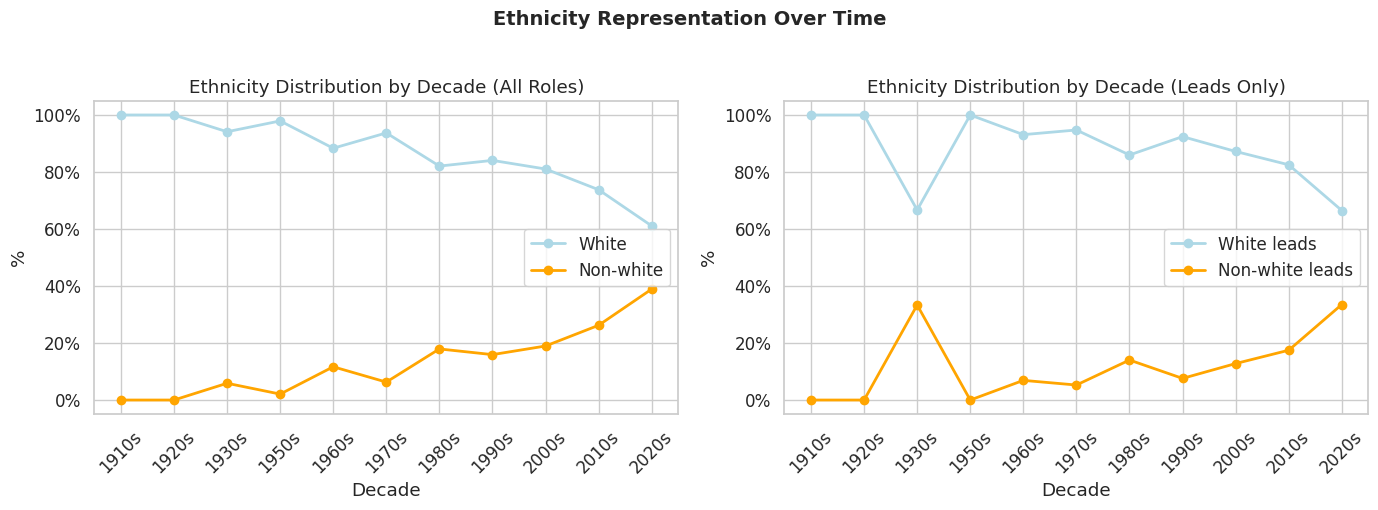

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

decades = named.groupby("decade")

# % White and non-white all roles
eth_decade = named.groupby("decade").apply(lambda x: pd.Series({
    "White": (x["actor_ethnicity"] == "White").mean() * 100,
    "Non-white": (x["actor_ethnicity"] != "White").mean() * 100,
})).reset_index()

ax = axes[0]
ax.plot(eth_decade["decade"], eth_decade["White"], marker="o", label="White", color="lightblue", linewidth=2)
ax.plot(eth_decade["decade"], eth_decade["Non-white"], marker="o", label="Non-white", color="orange", linewidth=2)
ax.set_title("Ethnicity Distribution by Decade (All Roles)")
ax.set_ylabel("%")
ax.set_xlabel("Decade")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# % White leads by decade
eth_leads_decade = leads.groupby("decade").apply(lambda x: pd.Series({
    "White": (x["actor_ethnicity"] == "White").mean() * 100,
    "Non-white": (x["actor_ethnicity"] != "White").mean() * 100,
})).reset_index()

ax = axes[1]
ax.plot(eth_leads_decade["decade"], eth_leads_decade["White"], marker="o", label="White leads", color="lightblue", linewidth=2)
ax.plot(eth_leads_decade["decade"], eth_leads_decade["Non-white"], marker="o", label="Non-white leads", color="orange", linewidth=2)
ax.set_title("Ethnicity Distribution by Decade (Leads Only)")
ax.set_ylabel("%")
ax.set_xlabel("Decade")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("Ethnicity Representation Over Time", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 3. Lead vs Supporting vs Minor: Gender & Ethnicity

These charts compare how gender and ethnicity are distributed across role tiers.
The prominence score bars show average narrative centrality within each tier and group.
A key question: are certain groups concentrated in minor roles even when they appear in a production?


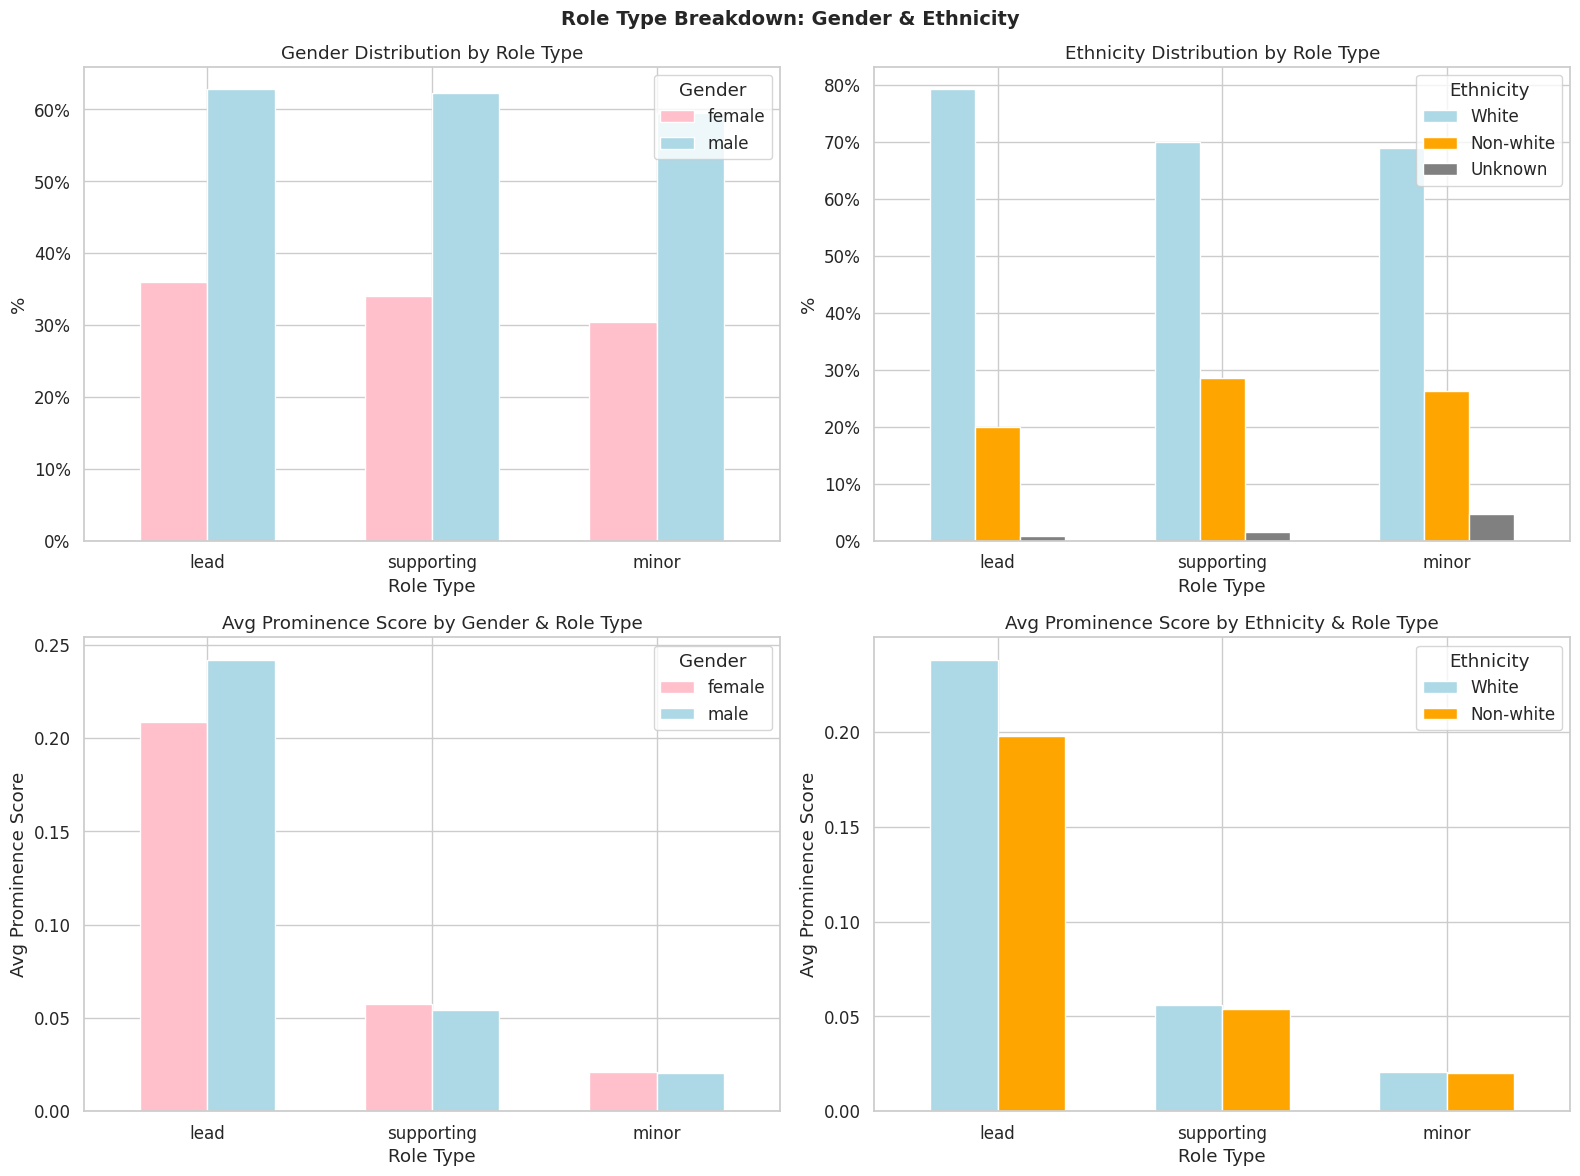

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender by role type
gender_role = named.groupby("role_type")["actor_gender"].value_counts(
    normalize=True).mul(100).unstack(fill_value=0).reindex(ROLE_ORDER)
gender_role[["female", "male"]].plot(kind="bar", ax=axes[0,0], color=["pink", "lightblue"], width=0.6)
axes[0,0].set_title("Gender Distribution by Role Type")
axes[0,0].set_ylabel("%")
axes[0,0].set_xlabel("Role Type")
axes[0,0].tick_params(axis="x", rotation=0)
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,0].legend(title="Gender")

# Ethnicity by role type
eth_role = named.groupby(["role_type", "ethnicity_simple"]).size().unstack(fill_value=0)
eth_role = eth_role.div(eth_role.sum(axis=1), axis=0).mul(100).reindex(ROLE_ORDER)
eth_role[["White", "Non-white", "Unknown"]].plot(kind="bar", ax=axes[0,1],
    color=["lightblue", "orange", "grey"], width=0.6)
axes[0,1].set_title("Ethnicity Distribution by Role Type")
axes[0,1].set_ylabel("%")
axes[0,1].set_xlabel("Role Type")
axes[0,1].tick_params(axis="x", rotation=0)
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,1].legend(title="Ethnicity")

# Prominence by gender and role type
prom_gender = named.groupby(["role_type", "actor_gender"])["prominence_score"].mean().unstack().reindex(ROLE_ORDER)
prom_gender[["female", "male"]].plot(kind="bar", ax=axes[1,0], color=["pink", "lightblue"], width=0.6)
axes[1,0].set_title("Avg Prominence Score by Gender & Role Type")
axes[1,0].set_ylabel("Avg Prominence Score")
axes[1,0].set_xlabel("Role Type")
axes[1,0].tick_params(axis="x", rotation=0)
axes[1,0].legend(title="Gender")

# Prominence by ethnicity (simplified) and role type
prom_eth = named.groupby(["role_type", "ethnicity_simple"])["prominence_score"].mean().unstack().reindex(ROLE_ORDER)
prom_eth[["White", "Non-white"]].plot(kind="bar", ax=axes[1,1], color=["lightblue", "orange"], width=0.6)
axes[1,1].set_title("Avg Prominence Score by Ethnicity & Role Type")
axes[1,1].set_ylabel("Avg Prominence Score")
axes[1,1].set_xlabel("Role Type")
axes[1,1].tick_params(axis="x", rotation=0)
axes[1,1].legend(title="Ethnicity")

plt.suptitle("Role Type Breakdown: Gender & Ethnicity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Intersectionality: Gender × Ethnicity

These charts examine the combination of gender and ethnicity simultaneously.
The first chart shows lead role counts for each gender/ethnicity combination.
The prominence chart shows whether the ethnicity gap in narrative centrality differs by gender.

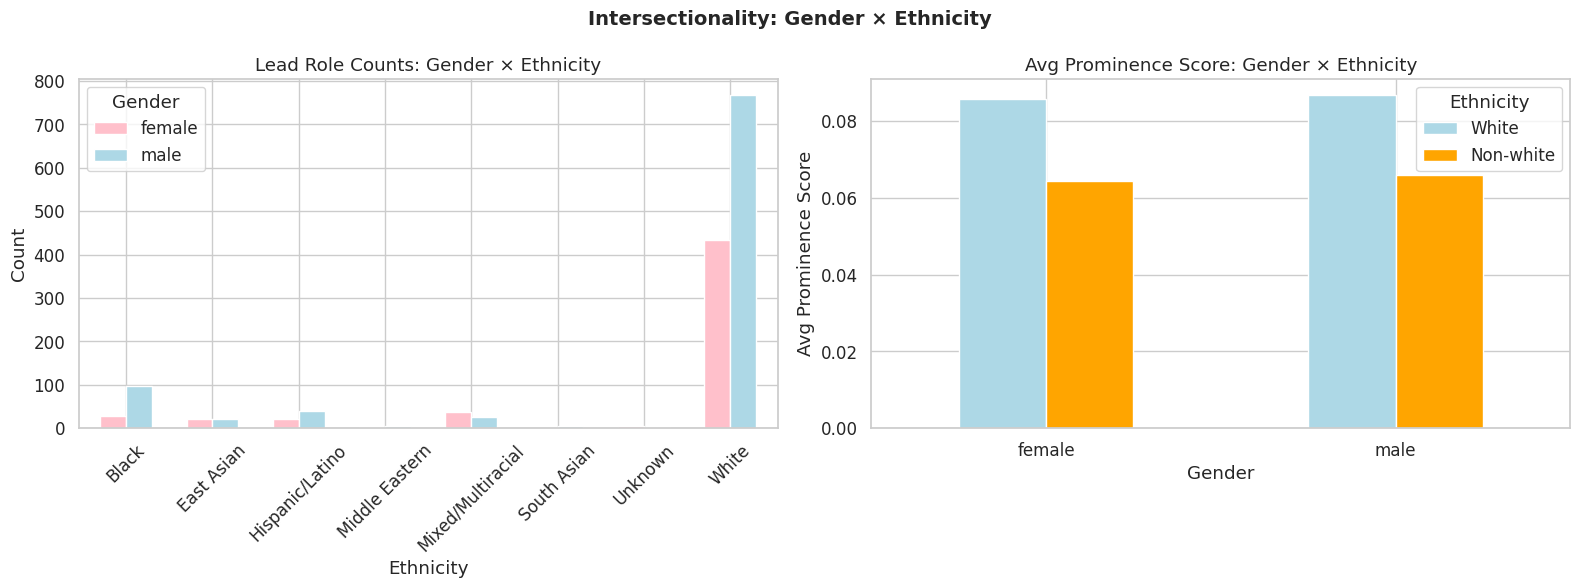


All roles — gender × ethnicity simplified (% of full dataset):
ethnicity_simple  Non-white  Unknown  White
actor_gender                               
female                  9.6      1.0   22.4
male                   14.9      1.0   45.4
unspecified             1.4      0.6    3.6


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lead counts by gender × ethnicity
intersect_leads = leads.groupby(["actor_gender", "actor_ethnicity"]).size().unstack(fill_value=0)
intersect_leads = intersect_leads.loc[intersect_leads.index.isin(["female", "male"])]
intersect_leads.T.plot(kind="bar", ax=axes[0], color=["pink", "lightblue"], width=0.6)
axes[0].set_title("Lead Role Counts: Gender × Ethnicity")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Gender")

# Prominence by gender × ethnicity simplified
prom_intersect = named.groupby(["actor_gender", "ethnicity_simple"])["prominence_score"].mean().unstack()
prom_intersect = prom_intersect.loc[prom_intersect.index.isin(["female", "male"])]
prom_intersect[["White", "Non-white"]].plot(kind="bar", ax=axes[1],
    color=["lightblue", "orange"], width=0.5)
axes[1].set_title("Avg Prominence Score: Gender × Ethnicity")
axes[1].set_ylabel("Avg Prominence Score")
axes[1].set_xlabel("Gender")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Ethnicity")

plt.suptitle("Intersectionality: Gender × Ethnicity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print the all-roles percentage table
print("\nAll roles — gender × ethnicity simplified (% of full dataset):")
intersect_all = named.groupby(["actor_gender", "ethnicity_simple"]).size().unstack(fill_value=0)
print(intersect_all.div(intersect_all.sum().sum()).mul(100).round(1).to_string())


## 5. Film vs TV: Gender & Ethnicity

TV and film operate under different production structures, audience expectations, and network pressures.
This section tests whether representation metrics differ significantly between the two formats,
and whether the gender and ethnicity gaps are more pronounced in one format than the other.


/tmp/ipykernel_3707/3338752871.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  media_summary = named.groupby("media_type").apply(lambda x: pd.Series({
/tmp/ipykernel_3707/3338752871.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  media_role = named.groupby(["media_type", "role_type"]).apply(


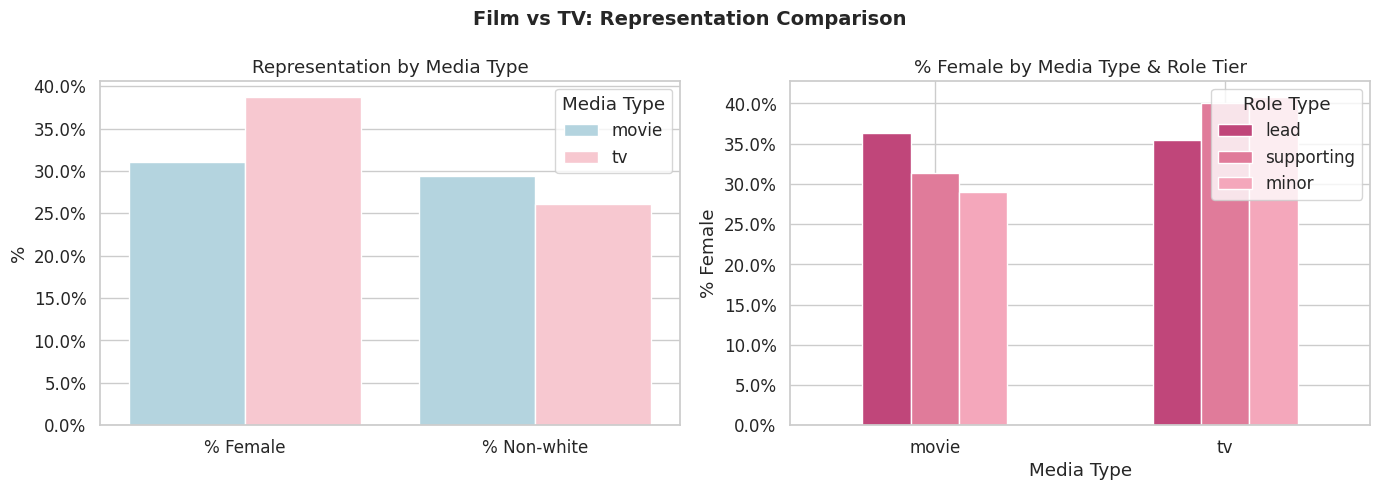

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall % female and % non-white by media type
media_summary = named.groupby("media_type").apply(lambda x: pd.Series({
    "% Female":    (x["actor_gender"] == "female").mean() * 100,
    "% Non-white": (x["actor_ethnicity"] != "White").mean() * 100,
})).reset_index()

media_melted = media_summary.melt(id_vars="media_type", var_name="metric", value_name="value")
sns.barplot(data=media_melted, x="metric", y="value", hue="media_type",
            palette={"movie": "lightblue", "tv": "pink"}, ax=axes[0])
axes[0].set_title("Representation by Media Type")
axes[0].set_ylabel("%")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title="Media Type")

# % female by media type and role tier
media_role = named.groupby(["media_type", "role_type"]).apply(
    lambda x: (x["actor_gender"] == "female").mean() * 100
).unstack()
media_role = media_role[ROLE_ORDER]
media_role.plot(kind="bar", ax=axes[1], color=["#C0467A", "#E07B9A", "#F4A7BB"], width=0.5)
axes[1].set_title("% Female by Media Type & Role Tier")
axes[1].set_ylabel("% Female")
axes[1].set_xlabel("Media Type")
axes[1].tick_params(axis="x", rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title="Role Type")

plt.suptitle("Film vs TV: Representation Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Genre Breakdown

Genre conventions strongly shape who gets cast. War films skew male; romance and mystery tend toward
more balanced casts. This section ranks genres by female and non-white representation to show
which genres are most and least diverse. Only genres with at least 10 cast members are included.


/tmp/ipykernel_3707/3756513513.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_gender = named.groupby("genre_primary").apply(
/tmp/ipykernel_3707/3756513513.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_eth = named.groupby("genre_primary").apply(


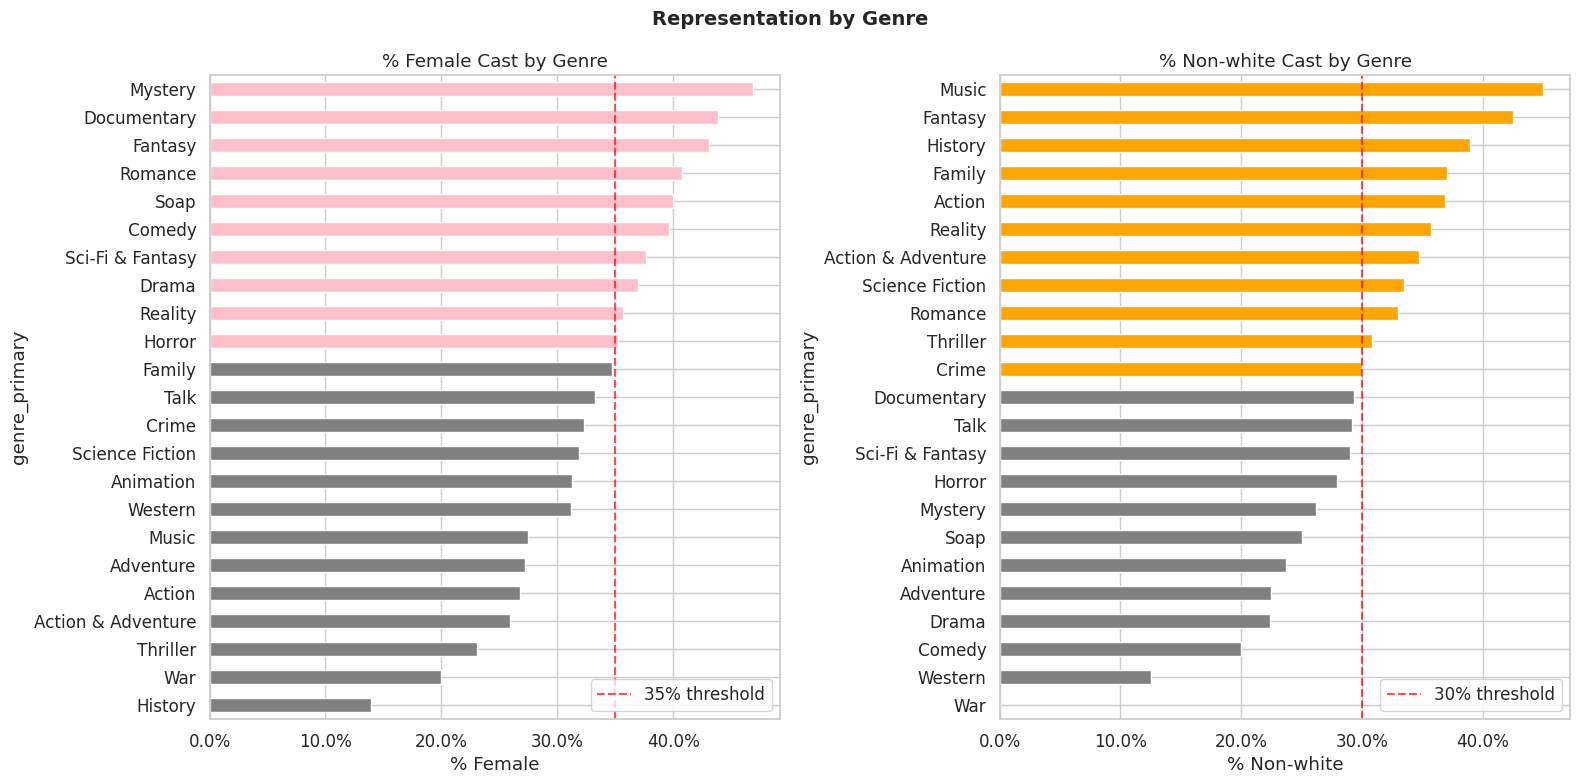

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

genre_gender = named.groupby("genre_primary").apply(
    lambda x: (x["actor_gender"] == "female").mean() * 100 if len(x) >= 10 else None
).dropna().round(1).sort_values()

genre_eth = named.groupby("genre_primary").apply(
    lambda x: (x["actor_ethnicity"] != "White").mean() * 100 if len(x) >= 10 else None
).dropna().round(1).sort_values()

colors_gender = ["pink" if v >= 35 else "grey" for v in genre_gender]
genre_gender.plot(kind="barh", ax=axes[0], color=colors_gender)
axes[0].axvline(35, color="red", linestyle="--", alpha=0.7, label="35% threshold")
axes[0].set_title("% Female Cast by Genre")
axes[0].set_xlabel("% Female")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()

colors_eth = ["orange" if v >= 30 else "grey" for v in genre_eth]
genre_eth.plot(kind="barh", ax=axes[1], color=colors_eth)
axes[1].axvline(30, color="red", linestyle="--", alpha=0.7, label="30% threshold")
axes[1].set_title("% Non-white Cast by Genre")
axes[1].set_xlabel("% Non-white")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.suptitle("Representation by Genre", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Statistical Tests with Benjamini-Hochberg Correction

All comparisons below use independent samples t-tests (or one-way ANOVA for genre comparisons),
corrected for multiple comparisons using the Benjamini-Hochberg procedure at FDR = 0.05.

Why Benjamini-Hochberg? Running 13 tests simultaneously inflates the chance of false positives, and
Benjamini-Hochberg controls the false discovery rate. At FDR = 0.05, at most 5% of significant findings are expected to be spurious.

Effect sizes are reported alongside p-values so findings are interpretable, not just statistically significant.
Cohen's d measures the standardized difference between group means: small ≈ 0.2, medium ≈ 0.5, large ≈ 0.8.


In [21]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

def fmt_p(p):
    if p < 0.0001:
        return f"{p:.2e}"
    return f"{p:.4f}"

tests = []

def add_test(name, a, b, tests, test_type="ttest"):
    if test_type == "ttest":
        _, p = stats.ttest_ind(a, b)
        d = abs(cohens_d(a, b))
        comparison = f"{a.mean()*100:.1f}% vs {b.mean()*100:.1f}%" if a.max() <= 1 else f"{a.mean():.4f} vs {b.mean():.4f}"
    else:
        _, p = stats.f_oneway(*a)
        d, comparison = None, "ANOVA — see genre chart"
    tests.append((name, p, d, comparison))

tests = []

add_test("Female representation: leads vs non-leads",
    (named[named["role_type"] == "lead"]["actor_gender"] == "female").astype(float),
    (named[named["role_type"] != "lead"]["actor_gender"] == "female").astype(float), tests)

add_test("Non-white representation: leads vs non-leads",
    (named[named["role_type"] == "lead"]["actor_ethnicity"] != "White").astype(float),
    (named[named["role_type"] != "lead"]["actor_ethnicity"] != "White").astype(float), tests)

add_test("Prominence score: male vs female",
    named[named["actor_gender"] == "male"]["prominence_score"].dropna(),
    named[named["actor_gender"] == "female"]["prominence_score"].dropna(), tests)

add_test("Prominence score: White vs non-white",
    named[named["actor_ethnicity"] == "White"]["prominence_score"].dropna(),
    named[named["actor_ethnicity"] != "White"]["prominence_score"].dropna(), tests)

leads_80s = leads[leads["decade"] == "1980s"]
leads_10s = leads[leads["decade"] == "2010s"]
if len(leads_80s) > 0 and len(leads_10s) > 0:
    add_test("Female leads: 1980s vs 2010s",
        (leads_80s["actor_gender"] == "female").astype(float),
        (leads_10s["actor_gender"] == "female").astype(float), tests)

early_leads = named[named["decade"].isin(["1980s", "1990s"]) & (named["role_type"] == "lead")]
recent_leads = named[named["decade"].isin(["2010s", "2020s"]) & (named["role_type"] == "lead")]
if len(early_leads) > 0 and len(recent_leads) > 0:
    add_test("Non-white leads: early vs recent decades",
        (early_leads["actor_ethnicity"] != "White").astype(float),
        (recent_leads["actor_ethnicity"] != "White").astype(float), tests)

w_f = named[(named["actor_gender"] == "female") & (named["actor_ethnicity"] == "White")]["prominence_score"].dropna()
nw_f = named[(named["actor_gender"] == "female") & (named["actor_ethnicity"] != "White")]["prominence_score"].dropna()
w_m = named[(named["actor_gender"] == "male") & (named["actor_ethnicity"] == "White")]["prominence_score"].dropna()
nw_m = named[(named["actor_gender"] == "male") & (named["actor_ethnicity"] != "White")]["prominence_score"].dropna()

add_test("Prominence: white female vs non-white female", w_f, nw_f, tests)
add_test("Prominence: white male vs non-white male",     w_m, nw_m, tests)
print(f"Ethnicity prominence penalty — female: {(w_f.mean()-nw_f.mean()):.4f}, male: {(w_m.mean()-nw_m.mean()):.4f}")

add_test("Female representation: TV vs film",
    (named[named["media_type"] == "tv"]["actor_gender"] == "female").astype(float),
    (named[named["media_type"] == "movie"]["actor_gender"] == "female").astype(float), tests)

add_test("Non-white representation: TV vs film",
    (named[named["media_type"] == "tv"]["actor_ethnicity"] != "White").astype(float),
    (named[named["media_type"] == "movie"]["actor_ethnicity"] != "White").astype(float), tests)

genre_groups_g = [(named[named["genre_primary"] == g]["actor_gender"] == "female").astype(float)
    for g in named["genre_primary"].dropna().unique() if len(named[named["genre_primary"] == g]) >= 10]
if len(genre_groups_g) >= 2:
    add_test("Gender representation differs across genres", genre_groups_g, None, tests, test_type="anova")

genre_groups_e = [(named[named["genre_primary"] == g]["actor_ethnicity"] != "White").astype(float)
    for g in named["genre_primary"].dropna().unique() if len(named[named["genre_primary"] == g]) >= 10]
if len(genre_groups_e) >= 2:
    add_test("Ethnicity representation differs across genres", genre_groups_e, None, tests, test_type="anova")

test_names = [t[0] for t in tests]
p_values = [t[1] for t in tests]
effect_sizes = [t[2] for t in tests]
comparisons = [t[3] for t in tests]
reject, p_corrected, _, _ = multipletests(p_values, method="fdr_bh")

results_df = pd.DataFrame({
    "Test": test_names,
    "p-raw": [fmt_p(p) for p in p_values],
    "p-corrected": [fmt_p(p) for p in p_corrected],
    "Cohen's d": [f"{d:.3f}" if d is not None else "—" for d in effect_sizes],
    "Comparison": comparisons,
    "Significant": ["YES" if r else "no" for r in reject]
})
display(results_df)
print("\nNote: Benjamini-Hochberg correction at FDR = 0.05")


Ethnicity prominence penalty — female: 0.0240, male: 0.0231


,Test,p-raw,p-corrected,Cohen's d,Comparison,Significant
0,Female representation: leads vs non-leads,0.0065,0.0077,0.077,35.9% vs 32.3%,YES
1,Non-white representation: leads vs non-leads,2.78e-14,1.11e-13,0.227,20.7% vs 30.5%,YES
2,Prominence score: male vs female,0.3235,0.3235,0.025,8.1% vs 7.8%,no
3,Prominence score: White vs non-white,3.51e-17,2.11e-16,0.229,8.4% vs 6.1%,YES
4,Female leads: 1980s vs 2010s,0.1744,0.1903,0.200,22.8% vs 31.7%,no
5,Non-white leads: early vs recent decades,7.21e-08,1.08e-07,0.471,9.4% vs 27.2%,YES
6,Prominence: white female vs non-white female,1.18e-08,2.02e-08,0.253,8.6% vs 6.2%,YES
7,Prominence: white male vs non-white male,2.94e-09,5.88e-09,0.215,8.7% vs 6.4%,YES
8,Female representation: TV vs film,7.82e-10,1.88e-09,0.161,38.7% vs 31.1%,YES
9,Non-white representation: TV vs film,0.0055,0.0073,0.074,26.1% vs 29.4%,YES



Note: Benjamini-Hochberg correction at FDR = 0.05


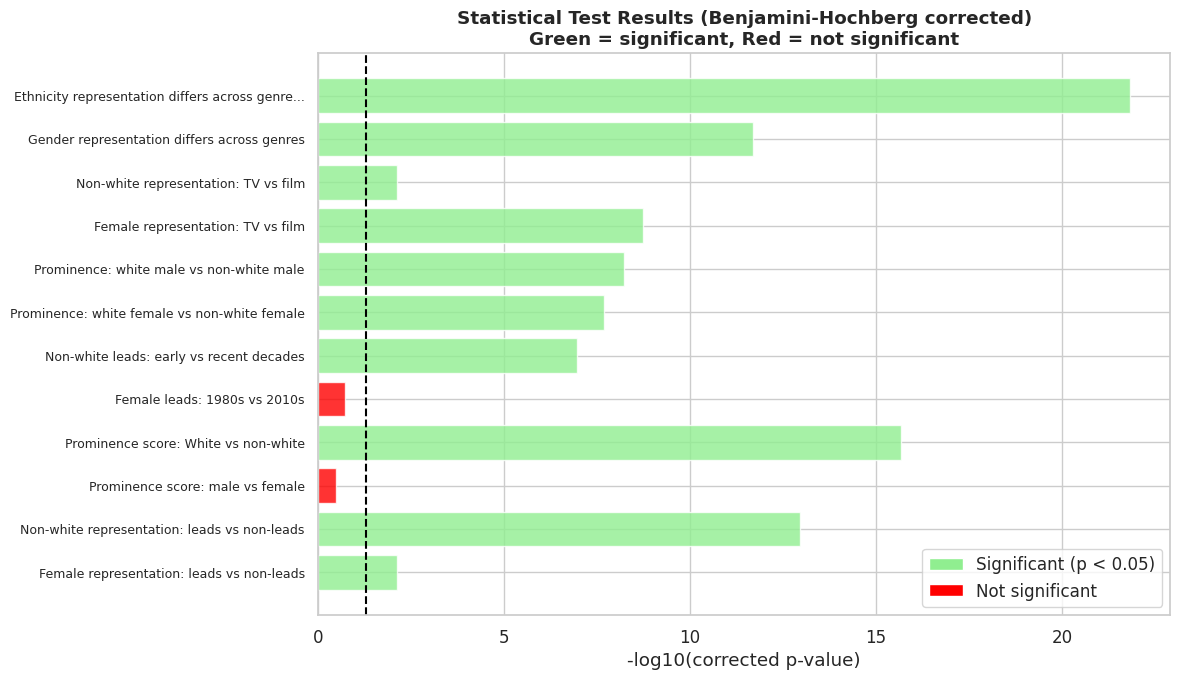

In [43]:
# summary of statistical test results
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["lightgreen" if r else "red" for r in reject]
p_display = [-np.log10(max(p, 1e-300)) for p in p_corrected]
short_names = [t[:45] + "..." if len(t) > 45 else t for t in test_names]

bars = ax.barh(range(len(short_names)), p_display, color=colors, alpha=0.8)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1.5, label="p = 0.05 threshold")
ax.set_yticks(range(len(short_names)))
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel("-log10(corrected p-value)")
ax.set_title("Statistical Test Results (Benjamini-Hochberg corrected)\nGreen = significant, Red = not significant", fontweight="bold")
ax.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="lightgreen", label="Significant (p < 0.05)"),
                   Patch(facecolor="red", label="Not significant")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()
